In [1]:
import pandas as pd

Check no duplicates and no unused rows

In [2]:
data = pd.read_csv('/raid2/jam247/JVGR_PAPER/Data/splitting_data/used/ACl_FILTERED_DATA_04.csv')

Check filters

In [5]:
print("Dtlag max:", data['Dtlag'].max())
print("Dfast max:", data['Dfast'].max())
print("anginc_epi max:", data['anginc_epi'].max())
print("tlag max:", data['tlag'].max())
print("gradeABCNR value_counts:\n", data['gradeABCNR'].value_counts())
# Print duplicate rows of '1event'
duplicates = data[data.duplicated(subset=['1event'], keep=False)]
print(f"Number of duplicates: {len(duplicates)}")

Dtlag max: 0.05
Dfast max: 10.0
anginc_epi max: 44.99977793799337
tlag max: 0.4
gradeABCNR value_counts:
 gradeABCNR
ACl    52856
Name: count, dtype: int64
Number of duplicates: 0


check length of data

In [8]:
print(len(data))

52856


Check bounds of the data

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

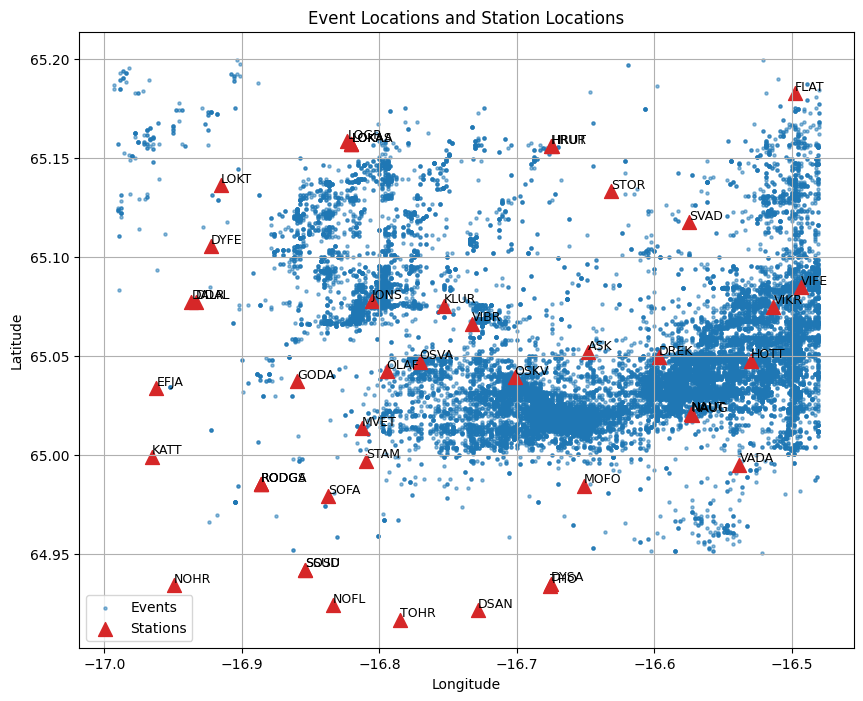

In [10]:
# Plot evlo (event longitude) vs evla (event latitude)
plt.figure(figsize=(10, 8))
plt.scatter(data['evlo'], data['evla'], s=5, color='tab:blue', alpha=0.5, label='Events')

# Also plot unique (slon, slat) pairs for stations and label them by stat
unique_stations = data[['slon', 'slat', 'stat']].drop_duplicates()
plt.scatter(unique_stations['slon'], unique_stations['slat'], 
            color='tab:red', marker='^', s=100, label='Stations')

# Add labels for stations
for _, row in unique_stations.iterrows():
    plt.text(row['slon'], row['slat'], row['stat'], fontsize=9, ha='left', va='bottom')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Event Locations and Station Locations')
plt.legend()
plt.grid(True)
plt.show()